# Track 6 Model Comparison

This notebook compares the summarization approaches for Track 6 using the evaluation outputs produced by `evaluation.py`.

Models compared:
- Hugging Face API LLM
- Local LLM
- Extractive baseline
- Hybrid/template baseline

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("data")

summary_files = {
    "LLM API": DATA_DIR / "track6_evaluation_summary.json",
    "Local LLM": DATA_DIR / "track6_evaluation_summary_local_llm.json",
    "Extractive": DATA_DIR / "track6_evaluation_summary_extractive.json",
    "Hybrid": DATA_DIR / "track6_evaluation_summary_hybrid.json",
}

summary_files

{'LLM API': WindowsPath('data/track6_evaluation_summary.json'),
 'Local LLM': WindowsPath('data/track6_evaluation_summary_local_llm.json'),
 'Extractive': WindowsPath('data/track6_evaluation_summary_extractive.json'),
 'Hybrid': WindowsPath('data/track6_evaluation_summary_hybrid.json')}

## Load Evaluation Summaries

In [2]:
rows = []

for model_name, path in summary_files.items():
    if not path.exists():
        print(f"Missing: {path}")
        continue
    with path.open("r", encoding="utf-8") as f:
        metrics = json.load(f)
    rows.append({"model": model_name, **metrics})

comparison = pd.DataFrame(rows)
comparison

,model,average_word_count,critical_entity_preservation_ok_rate,has_account_numbers_rate,has_amount_rate,has_banks_rate,has_counterparty_rate,has_customer_rate,has_date_rate,has_transaction_mode_rate,length_ok_rate,max_word_count,min_word_count,overall_ok_rate,strict_entity_preservation_ok_rate,total_summaries
0,LLM API,117.70,1.0000,1.0,1.0000,1.0000,1.0000,1.0,1.0000,1.0000,0.8000,133,98,0.8000,1.0,10
1,Local LLM,101.00,0.0000,0.7,0.6000,0.6000,1.0000,1.0,0.7000,0.3000,0.6000,151,44,0.0000,0.0,10
2,Extractive,121.11,0.0000,0.0,0.0000,0.0399,0.6232,1.0,0.6377,0.1413,0.6377,193,9,0.0000,0.0,276
3,Hybrid,75.30,0.6377,0.0,0.6377,0.6377,0.6377,1.0,0.6377,0.6377,0.6377,118,9,0.6377,0.0,276


## Core Comparison Table

In [3]:
metric_cols = [
    "model",
    "total_summaries",
    "average_word_count",
    "length_ok_rate",
    "critical_entity_preservation_ok_rate",
    "strict_entity_preservation_ok_rate",
    "overall_ok_rate",
    "has_customer_rate",
    "has_counterparty_rate",
    "has_banks_rate",
    "has_amount_rate",
    "has_date_rate",
    "has_transaction_mode_rate",
    "has_account_numbers_rate",
]

available_cols = [col for col in metric_cols if col in comparison.columns]
comparison_table = comparison[available_cols].sort_values(
    ["overall_ok_rate", "critical_entity_preservation_ok_rate", "length_ok_rate"],
    ascending=False,
)

comparison_table

,model,total_summaries,average_word_count,length_ok_rate,critical_entity_preservation_ok_rate,strict_entity_preservation_ok_rate,overall_ok_rate,has_customer_rate,has_counterparty_rate,has_banks_rate,has_amount_rate,has_date_rate,has_transaction_mode_rate,has_account_numbers_rate
0,LLM API,10,117.70,0.8000,1.0000,1.0,0.8000,1.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0
3,Hybrid,276,75.30,0.6377,0.6377,0.0,0.6377,1.0,0.6377,0.6377,0.6377,0.6377,0.6377,0.0
2,Extractive,276,121.11,0.6377,0.0000,0.0,0.0000,1.0,0.6232,0.0399,0.0000,0.6377,0.1413,0.0
1,Local LLM,10,101.00,0.6000,0.0000,0.0,0.0000,1.0,1.0000,0.6000,0.6000,0.7000,0.3000,0.7


## Presentation-Friendly Percent Table

In [4]:
percent_cols = [
    "length_ok_rate",
    "critical_entity_preservation_ok_rate",
    "strict_entity_preservation_ok_rate",
    "overall_ok_rate",
    "has_account_numbers_rate",
]

display_table = comparison_table.copy()
for col in percent_cols:
    if col in display_table.columns:
        display_table[col] = (display_table[col] * 100).round(1).astype(str) + "%"

display_table

,model,total_summaries,average_word_count,length_ok_rate,critical_entity_preservation_ok_rate,strict_entity_preservation_ok_rate,overall_ok_rate,has_customer_rate,has_counterparty_rate,has_banks_rate,has_amount_rate,has_date_rate,has_transaction_mode_rate,has_account_numbers_rate
0,LLM API,10,117.70,80.0%,100.0%,100.0%,80.0%,1.0,1.0000,1.0000,1.0000,1.0000,1.0000,100.0%
3,Hybrid,276,75.30,63.8%,63.8%,0.0%,63.8%,1.0,0.6377,0.6377,0.6377,0.6377,0.6377,0.0%
2,Extractive,276,121.11,63.8%,0.0%,0.0%,0.0%,1.0,0.6232,0.0399,0.0000,0.6377,0.1413,0.0%
1,Local LLM,10,101.00,60.0%,0.0%,0.0%,0.0%,1.0,1.0000,0.6000,0.6000,0.7000,0.3000,70.0%


## Plot Key Metrics

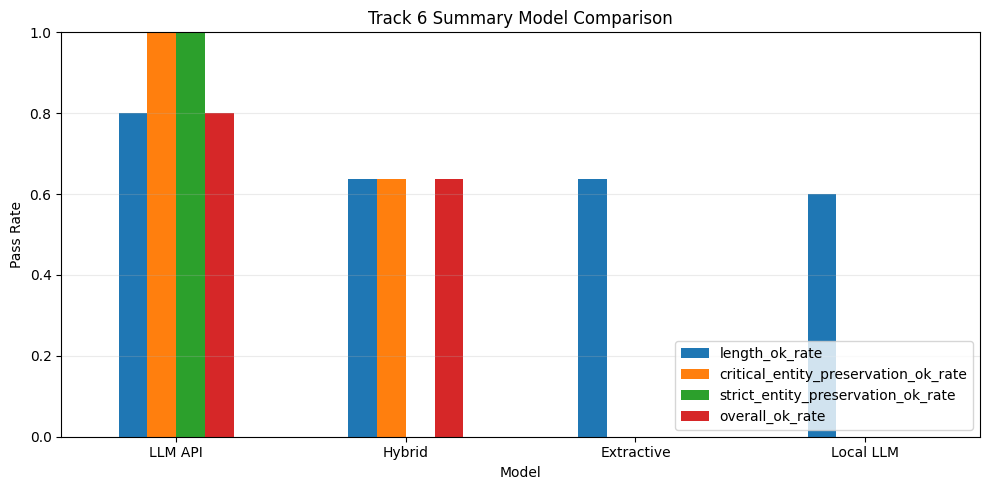

In [5]:
plot_cols = [
    "length_ok_rate",
    "critical_entity_preservation_ok_rate",
    "strict_entity_preservation_ok_rate",
    "overall_ok_rate",
]

plot_df = comparison_table.set_index("model")[[col for col in plot_cols if col in comparison_table.columns]]

ax = plot_df.plot(kind="bar", figsize=(10, 5), ylim=(0, 1), rot=0)
ax.set_title("Track 6 Summary Model Comparison")
ax.set_ylabel("Pass Rate")
ax.set_xlabel("Model")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Best Model Selection

In [6]:
best_model = comparison_table.iloc[0]

print("Best model:", best_model["model"])
print("Overall pass rate:", round(best_model["overall_ok_rate"] * 100, 1), "%")
print("Critical entity preservation:", round(best_model["critical_entity_preservation_ok_rate"] * 100, 1), "%")
print("Length pass rate:", round(best_model["length_ok_rate"] * 100, 1), "%")

Best model: LLM API
Overall pass rate: 80.0 %
Critical entity preservation: 100.0 %
Length pass rate: 80.0 %


## Save Comparison Artifacts

In [7]:
output_csv = DATA_DIR / "track6_model_comparison_results.csv"
output_json = DATA_DIR / "track6_model_comparison_summary.json"

comparison_table.to_csv(output_csv, index=False)

payload = {
    "best_model": str(best_model["model"]),
    "models": comparison_table.to_dict(orient="records"),
}

with output_json.open("w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)

print("Saved:", output_csv)
print("Saved:", output_json)

Saved: data\track6_model_comparison_results.csv
Saved: data\track6_model_comparison_summary.json


## Demo Examples

Prepare 3-5 presentation examples that show the original STR narrative, extracted facts, generated summary, and validation result.

In [ ]:
evaluation_results_path = DATA_DIR / "track6_evaluation_results.csv"
demo_output_path = DATA_DIR / "track6_demo_examples.md"

eval_df = pd.read_csv(evaluation_results_path)
eval_df = eval_df.copy()
eval_df["overall_ok"] = eval_df["overall_ok"].astype(bool)
eval_df["critical_entity_preservation_ok"] = eval_df["critical_entity_preservation_ok"].astype(bool)
eval_df["strict_entity_preservation_ok"] = eval_df["strict_entity_preservation_ok"].astype(bool)

print("Available evaluated reports:", len(eval_df))
print(eval_df["report_type"].value_counts().to_string())

In [ ]:
def first_rows(frame, n):
    return frame.sort_values(["overall_ok", "narrative_length", "report_id"], ascending=[False, True, True]).head(n)

demo_parts = []

# One Type-A minimal narrative, preferably passing.
type_a = eval_df[eval_df["report_type"].eq("Type-A")]
demo_parts.append(first_rows(type_a[type_a["overall_ok"]], 1))
if demo_parts[-1].empty:
    demo_parts[-1] = first_rows(type_a, 1)

# Two Type-B detailed narratives, preferably passing.
type_b = eval_df[eval_df["report_type"].eq("Type-B")]
demo_parts.append(first_rows(type_b[type_b["overall_ok"]], 2))
if len(demo_parts[-1]) < 2:
    already = pd.concat(demo_parts)["report_id"].tolist()
    fallback_b = type_b[~type_b["report_id"].isin(already)]
    demo_parts[-1] = pd.concat([demo_parts[-1], first_rows(fallback_b, 2 - len(demo_parts[-1]))])

# One failed or edge case if available.
already = pd.concat(demo_parts)["report_id"].tolist()
failed_or_edge = eval_df[(~eval_df["overall_ok"]) & (~eval_df["report_id"].isin(already))]
if failed_or_edge.empty:
    failed_or_edge = eval_df[~eval_df["report_id"].isin(already)].sort_values("narrative_length", ascending=False).head(1)
else:
    failed_or_edge = failed_or_edge.sort_values(["critical_entity_preservation_ok", "narrative_length", "report_id"], ascending=[True, False, True]).head(1)
demo_parts.append(failed_or_edge)

demo_examples = pd.concat(demo_parts).drop_duplicates("report_id").reset_index(drop=True)
demo_examples[["report_id", "report_type", "narrative_length", "word_count", "overall_ok", "critical_entity_preservation_ok", "strict_entity_preservation_ok"]]

In [ ]:
def clean_value(value):
    if pd.isna(value) or value == "":
        return "Not found"
    return str(value)

def short_text(value, limit=650):
    text = " ".join(clean_value(value).split())
    return text if len(text) <= limit else text[: limit - 3].rstrip() + "..."

def extracted_facts(row):
    facts = {
        "customer": clean_value(row.get("entities_customer_names")),
        "counterparty": clean_value(row.get("entities_counterparty_names")),
        "banks": clean_value(row.get("entities_bank_names")),
        "amounts": clean_value(row.get("entities_amounts")),
        "dates": clean_value(row.get("entities_dates")),
        "transaction_modes": clean_value(row.get("entities_transaction_modes")),
        "from_account": clean_value(row.get("from_account_number")),
        "to_account": clean_value(row.get("to_account_number")),
    }
    return "; ".join(f"{key}: {value}" for key, value in facts.items())

def validation_result(row):
    status = "PASS" if bool(row["overall_ok"]) else "FAIL"
    checks = []
    checks.append("length ok" if bool(row["length_ok"]) else "length outside 100-200 words")
    checks.append("critical facts preserved" if bool(row["critical_entity_preservation_ok"]) else "critical facts missing")
    checks.append("strict facts preserved" if bool(row["strict_entity_preservation_ok"]) else "strict facts missing")
    return f"{status}: " + "; ".join(checks)

demo_table = demo_examples.apply(
    lambda row: pd.Series({
        "report_id": row["report_id"],
        "report_type": row["report_type"],
        "original_narrative": short_text(row["narrative"]),
        "extracted_facts": extracted_facts(row),
        "summary": short_text(row["summary"]),
        "validation_result": validation_result(row),
    }),
    axis=1,
)

demo_table

In [ ]:
def markdown_escape(value):
    text = str(value).replace("\n", " ")
    return text.replace("|", "\\|")

def dataframe_to_markdown(frame):
    columns = list(frame.columns)
    header = "| " + " | ".join(columns) + " |"
    separator = "| " + " | ".join(["---"] * len(columns)) + " |"
    rows = []
    for _, row in frame.iterrows():
        rows.append("| " + " | ".join(markdown_escape(row[col]) for col in columns) + " |")
    return "\n".join([header, separator] + rows)

with demo_output_path.open("w", encoding="utf-8") as f:
    f.write("# Track 6 Demo Examples\n\n")
    f.write("These examples show the narrative, extracted facts, generated summary, and validation result for presentation.\n\n")
    f.write(dataframe_to_markdown(demo_table))
    f.write("\n")

print("Saved:", demo_output_path)

## Notes For Presentation

- `overall_ok_rate` is the most important combined metric because it requires both correct length and critical fact preservation.
- `strict_entity_preservation_ok_rate` additionally checks account numbers.
- Extractive and hybrid baselines are useful for comparison, but a model that drops amounts, banks, dates, or account numbers is not acceptable for this domain even if it sounds fluent.
- The final model should be selected based on factual faithfulness first, then length and fluency.